In [2]:
# Import necessary librarys 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from prophet import Prophet
from datetime import timedelta
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.style.use('ggplot')
plt.style.use('bmh')

In [3]:
demandNSW = pd.read_csv("/Users/benjamintrojko/Library/CloudStorage/Dropbox/University/24H5 ZZSC9020 Data Science Project/data/NSW/totaldemand_nsw.csv",
                        index_col=[0],
                        parse_dates=[0],
                        date_format = '%d/%m/%Y %H:%M')
demandNSW_clean = demandNSW.dropna()
demandNSW_clean.drop(['REGIONID'], axis=1, inplace=True)
# demandNSW_clean['DATETIME'] = pd.to_datetime(demandNSW_clean['DATETIME'], format='%d/%m/%Y %H:%M')

print(demandNSW_clean.shape)
print(demandNSW_clean.dtypes)
print(demandNSW_clean.describe())
demandNSW_clean

(196513, 1)
TOTALDEMAND    float64
dtype: object
         TOTALDEMAND
count  196513.000000
mean     8113.145859
std      1299.532774
min      5074.630000
25%      7150.070000
50%      8053.230000
75%      8958.550000
max     14579.860000


,TOTALDEMAND
DATETIME,
2010-01-01 00:00:00,8038.00
2010-01-01 00:30:00,7809.31
2010-01-01 01:00:00,7483.69
2010-01-01 01:30:00,7117.23
2010-01-01 02:00:00,6812.03
...,...
2021-03-17 22:00:00,7419.77
2021-03-17 22:30:00,7417.91
2021-03-17 23:00:00,7287.32


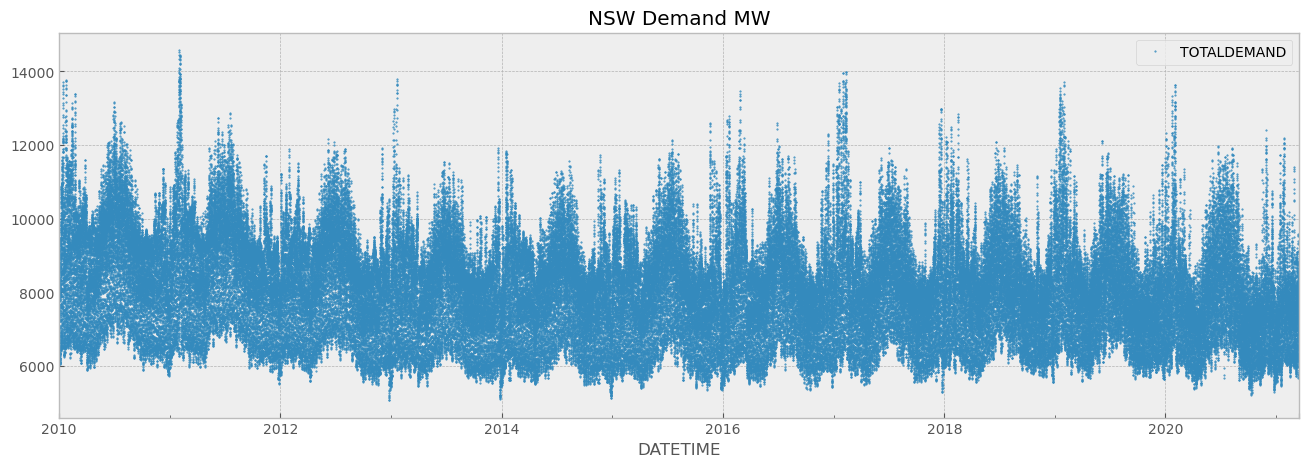

In [4]:
color_pal = sns.color_palette()
demandNSW_clean.plot(style='.',
          figsize=(16, 5),
          ms=1,
          title='NSW Demand MW')
plt.show()

In [5]:
# Function to add season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Summer'
    elif month in [3, 4, 5]:
        return 'Autumn'
    elif month in [6, 7, 8]:
        return 'Winter'
    else:
        return 'Spring'

## Time Series Features

In [9]:
demandNSW_clean2 = demandNSW_clean.copy()
demandNSW_clean2['date'] = demandNSW_clean2.index
demandNSW_clean2['hour'] = demandNSW_clean2['date'].dt.hour
demandNSW_clean2['time'] = (demandNSW_clean2.date.dt.hour * 60 + demandNSW_clean2.date.dt.minute) / 60
demandNSW_clean2['dayofweek'] = demandNSW_clean2['date'].dt.dayofweek
demandNSW_clean2['weekday'] = demandNSW_clean2['date'].dt.day_name()
demandNSW_clean2['weekday'] = demandNSW_clean2['date'].dt.dayofweek
demandNSW_clean2['quarter'] = demandNSW_clean2['date'].dt.quarter
demandNSW_clean2['month'] = demandNSW_clean2['date'].dt.month
demandNSW_clean2['year'] = demandNSW_clean2['date'].dt.year
demandNSW_clean2['dayofyear'] = demandNSW_clean2['date'].dt.dayofyear
demandNSW_clean2['dayofmonth'] = demandNSW_clean2['date'].dt.day
demandNSW_clean2['weekofyear'] = demandNSW_clean2['date'].dt.isocalendar().week
demandNSW_clean2['season'] = demandNSW_clean2['date'].dt.month.apply(get_season)


demandNSW_clean2

,TOTALDEMAND,date,hour,time,dayofweek,weekday,quarter,month,year,dayofyear,dayofmonth,weekofyear,season
DATETIME,,,,,,,,,,,,,
2010-01-01 00:00:00,8038.00,2010-01-01 00:00:00,0,0.0,4,4,1,1,2010,1,1,53,Summer
2010-01-01 00:30:00,7809.31,2010-01-01 00:30:00,0,0.5,4,4,1,1,2010,1,1,53,Summer
2010-01-01 01:00:00,7483.69,2010-01-01 01:00:00,1,1.0,4,4,1,1,2010,1,1,53,Summer
2010-01-01 01:30:00,7117.23,2010-01-01 01:30:00,1,1.5,4,4,1,1,2010,1,1,53,Summer
2010-01-01 02:00:00,6812.03,2010-01-01 02:00:00,2,2.0,4,4,1,1,2010,1,1,53,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-03-17 22:00:00,7419.77,2021-03-17 22:00:00,22,22.0,2,2,1,3,2021,76,17,11,Autumn
2021-03-17 22:30:00,7417.91,2021-03-17 22:30:00,22,22.5,2,2,1,3,2021,76,17,11,Autumn
2021-03-17 23:00:00,7287.32,2021-03-17 23:00:00,23,23.0,2,2,1,3,2021,76,17,11,Autumn


In [10]:
X = demandNSW_clean2[['time','dayofweek','quarter','month','year',
                    'dayofyear','dayofmonth','weekofyear','weekday',
                    'season']]
y = demandNSW_clean2['TOTALDEMAND']
features_and_target = pd.concat([X, y], axis=1)

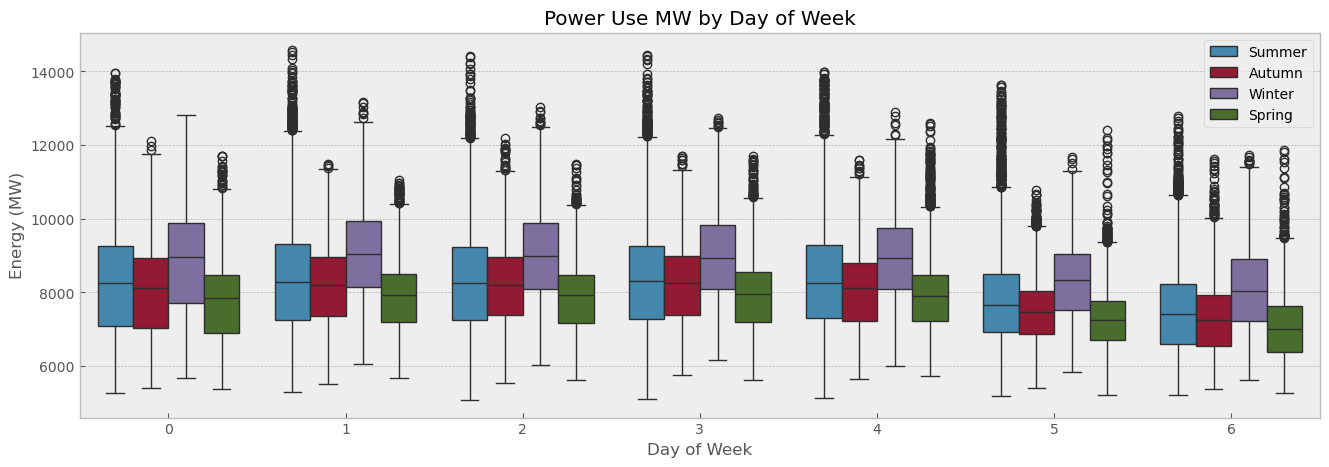

In [11]:
fig, ax = plt.subplots(figsize=(16, 5))
sns.boxplot(data=features_and_target.dropna(),
            x='weekday',
            y='TOTALDEMAND',
            hue='season',
            ax=ax,
            linewidth=1)
ax.set_title('Power Use MW by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Energy (MW)')
ax.legend(bbox_to_anchor=(1, 1))
plt.show()

## Prophet Model

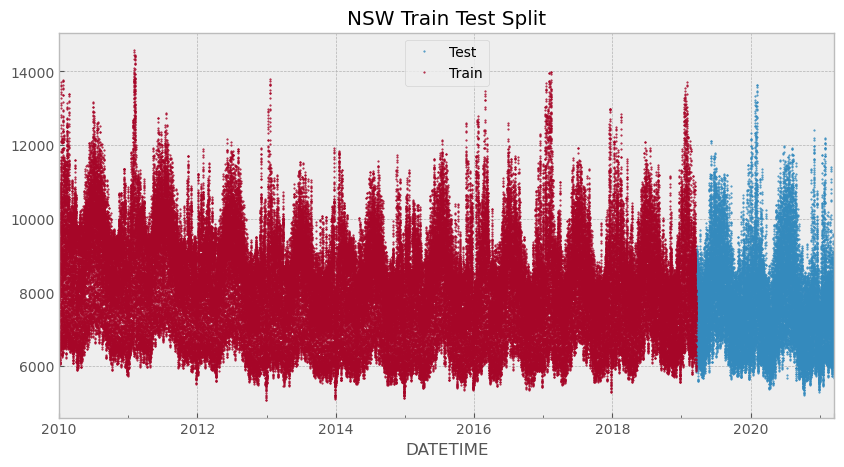

In [12]:
split_date = '18-Mar-2019'
demandNSW_clean_train = demandNSW_clean.loc[demandNSW_clean.index <= split_date].copy()
demandNSW_clean_test = demandNSW_clean.loc[demandNSW_clean.index > split_date].copy()

demandNSW_clean_test \
    .rename(columns={'TOTALDEMAND': 'Test'}) \
    .join(demandNSW_clean_train.rename(columns={'TOTALDEMAND': 'Train'}),
          how='outer') \
    .plot(figsize=(10, 5), title='NSW Train Test Split', style='.', ms=1)
plt.show()

In [13]:
# Rename columns to match Prophet's requirements
demandNSW_clean_train_prophet = demandNSW_clean_train.reset_index() \
    .rename(columns={'DATETIME':'ds',
                     'TOTALDEMAND':'y'})

demandNSW_clean_train_prophet

,ds,y
0,2010-01-01 00:00:00,8038.00
1,2010-01-01 00:30:00,7809.31
2,2010-01-01 01:00:00,7483.69
3,2010-01-01 01:30:00,7117.23
4,2010-01-01 02:00:00,6812.03
...,...,...
161420,2019-03-17 22:00:00,7117.35
161421,2019-03-17 22:30:00,7133.74
161422,2019-03-17 23:00:00,6948.63
161423,2019-03-17 23:30:00,6806.79


In [14]:
%%time
model = Prophet()
model.fit(demandNSW_clean_train_prophet)

11:18:43 - cmdstanpy - INFO - Chain [1] start processing


KeyboardInterrupt: 

In [31]:
# Predict on test set with model
demandNSW_clean_test_prophet = demandNSW_clean_test.reset_index() \
    .rename(columns={'DATETIME':'ds',
                     'TOTALDEMAND':'y'})

demandNSW_test_fcst = model.predict(demandNSW_clean_test_prophet)
demandNSW_test_fcst.head()

KeyError: 'k'

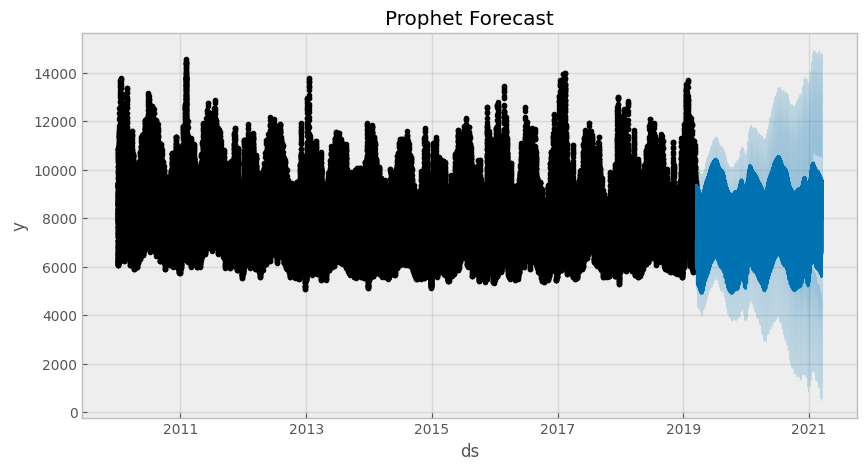

In [58]:
fig, ax = plt.subplots(figsize=(10, 5))
fig = model.plot(demandNSW_test_fcst, ax=ax)
ax.set_title('Prophet Forecast')
plt.show()

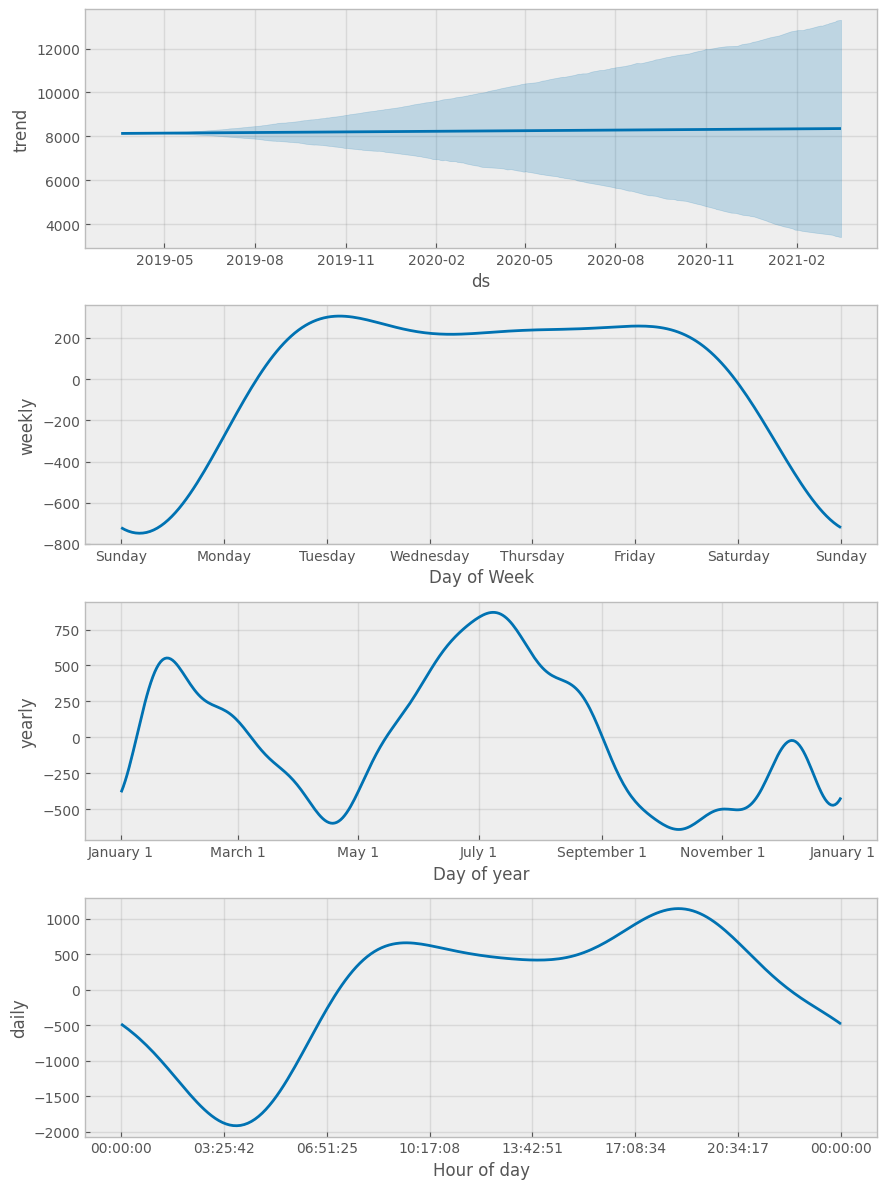

In [59]:
fig = model.plot_components(demandNSW_test_fcst)
plt.show()

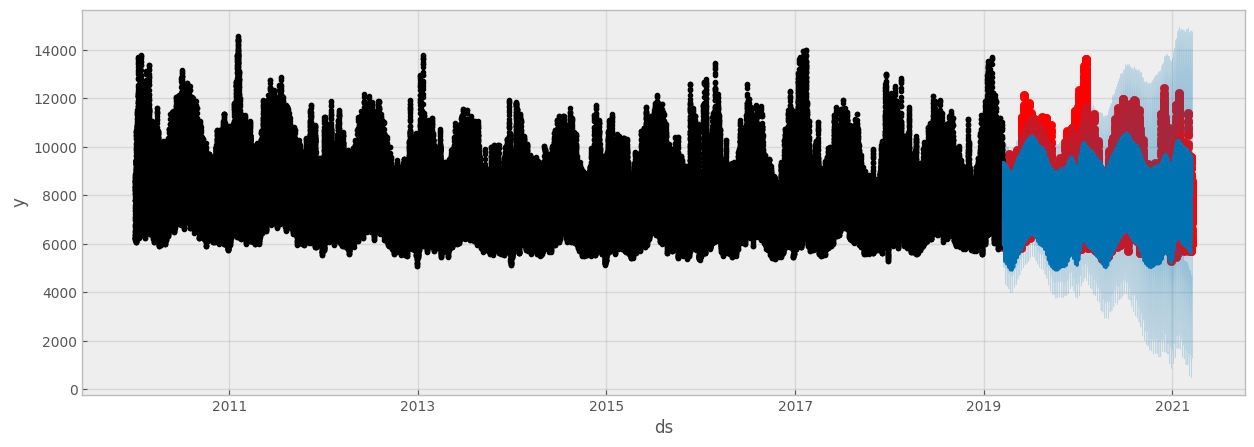

In [61]:
# Plot the forecast with the actuals
f, ax = plt.subplots(figsize=(15, 5))
ax.scatter(demandNSW_clean_test.index, demandNSW_clean_test['TOTALDEMAND'], color='r')
fig = model.plot(demandNSW_test_fcst, ax=ax)

## Public Holidays

In [16]:
import holidays
nsw_holidays = holidays.Australia(state='NSW', years=range(2010, 2023))
holidays_df = pd.DataFrame(list(nsw_holidays.items()), columns=['ds', 'holiday'])
holidays_df['ds'] = pd.to_datetime(holidays_df['ds'], format='%Y-%m-%d')
holidays_df

,ds,holiday
0,2016-03-25,Good Friday
1,2016-03-28,Easter Monday
2,2016-01-01,New Year's Day
3,2016-01-26,Australia Day
4,2016-03-26,Easter Saturday
...,...,...
151,2015-10-05,Labour Day
152,2015-06-08,Queen's Birthday
153,2015-12-25,Christmas Day
154,2015-12-26,Boxing Day


## Prophet Model with public holidays

In [17]:
%%time
model_with_holidays = Prophet(holidays=holidays_df)
model_with_holidays.fit(demandNSW_clean_train_prophet)

11:21:34 - cmdstanpy - INFO - Chain [1] start processing
11:22:31 - cmdstanpy - INFO - Chain [1] done processing


CPU times: user 3.18 s, sys: 306 ms, total: 3.48 s
Wall time: 59.8 s


In [97]:
demandNSW_test_fcst_with_hols = model_with_holidays.predict(df=demandNSW_clean_test_prophet)

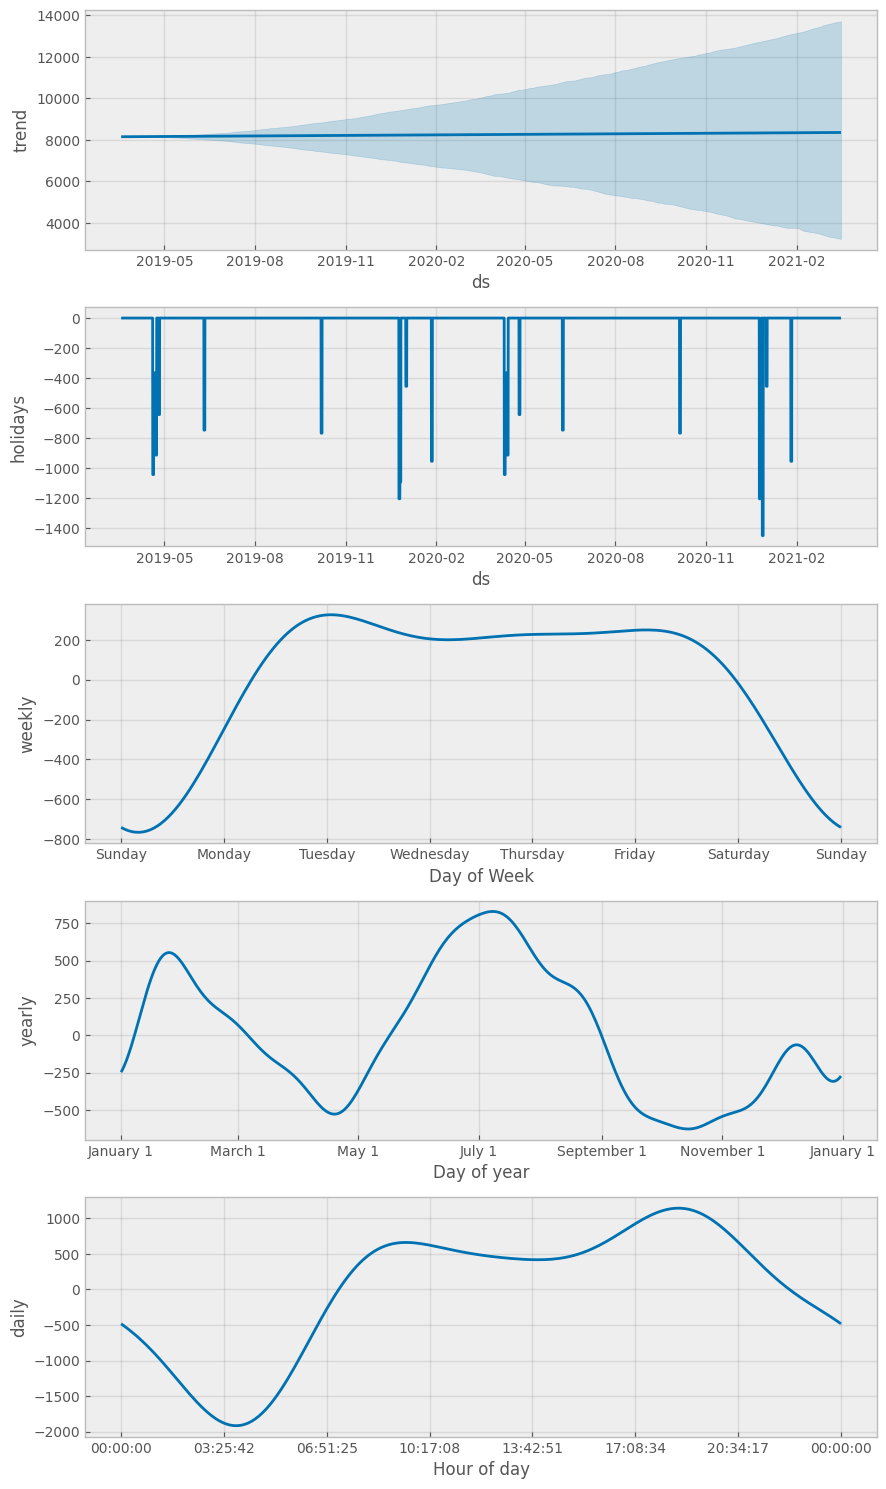

In [98]:
fig = model_with_holidays.plot_components(
    demandNSW_test_fcst_with_hols)
plt.show()

## Error Metrics from Prophet Model

In [116]:
mse1 = np.sqrt(mean_squared_error(y_true=demandNSW_clean_test['TOTALDEMAND'],
                   y_pred=demandNSW_test_fcst['yhat']))

mae1 = mean_absolute_error(y_true=demandNSW_clean_test['TOTALDEMAND'],
                   y_pred=demandNSW_test_fcst['yhat'])

print(f'Prophet model: \nMSE:{mse1}\nMAE:{mae1}')


Prophet model: 
MSE:957.2756644114615
MAE:754.2196982363529


In [118]:
mse2 = np.sqrt(mean_squared_error(y_true=demandNSW_clean_test['TOTALDEMAND'],
                   y_pred=demandNSW_test_fcst_with_hols['yhat']))

mae2 = mean_absolute_error(y_true=demandNSW_clean_test['TOTALDEMAND'],
                   y_pred=demandNSW_test_fcst_with_hols['yhat'])

print(f'Prophet model with holidays: \nMSE:{mse2}\nMAE:{mae2}')

Prophet model with holidays: 
MSE:945.2391750125023
MAE:747.2677730388931
